# A Tour of a Notebook

A single sitting with `numpy`, `pandas` and `matplotlib` — a table, a few
charts, a signal, a simulation and two pictures drawn out of arithmetic.

Everything here runs in a couple of seconds and downloads nothing.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import LinearSegmentedColormap

rng = np.random.default_rng(7)

## Color Palette Setup

In [2]:
# One palette, used by name everywhere below.
INK, MUTED = "#0b0b0b", "#52514e"
SERIES = {"Reykjavik": "#2a78d6", "Lisbon": "#eb6834", "Nairobi": "#1baf7a"}
BLUES = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]
blue = LinearSegmentedColormap.from_list("blue", BLUES)
divergent = LinearSegmentedColormap.from_list("bwr", ["#184f95", "#f0efec", "#d03b3b"])

In [3]:
plt.rcParams.update({
    "figure.figsize": (5.2, 3.4),
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": MUTED,
    "axes.labelcolor": MUTED,
    "axes.titlecolor": INK,
    "axes.titlelocation": "left",
    "axes.titleweight": "semibold",
    "axes.grid": True,
    "grid.color": "#e6e5e1",
    "text.color": INK,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "legend.frameon": False,
})

## 1 · A table to start from

Three cities, one year of daily weather. Real data would be a `read_csv`;
here it is a seasonal curve plus noise, so the notebook stays self-contained.

In [4]:
CITIES = {"Reykjavik": 4.0, "Lisbon": 17.0, "Nairobi": 25.0}

days = pd.date_range("2026-01-01", periods=365, freq="D")
seasonal = np.sin(2 * np.pi * (days.dayofyear - 100) / 365)

weather = pd.concat(
    pd.DataFrame({
        "date": days,
        "city": city,
        "temp_c": baseline + 8 * seasonal + rng.normal(0, 1.8, len(days)),
        "humidity": 72 - 18 * seasonal + rng.normal(0, 4, len(days)),
        "wind_kph": rng.gamma(shape=3.0, scale=4.0, size=len(days)),
    })
    for city, baseline in CITIES.items()
).reset_index(drop=True)

weather.head()

,date,city,temp_c,humidity,wind_kph
0,2026-01-01,Reykjavik,-3.926698,91.391881,4.565869
1,2026-01-02,Reykjavik,-3.408313,82.091910,11.195429
2,2026-01-03,Reykjavik,-4.454291,84.275759,13.063737
3,2026-01-04,Reykjavik,-5.576337,93.358417,12.729335
4,2026-01-05,Reykjavik,-4.801745,92.787449,8.746390


In [5]:
weather[["temp_c", "humidity", "wind_kph"]].describe().round(1)

,temp_c,humidity,wind_kph
count,1095.0,1095.0,1095.0
mean,15.3,71.8,12.0
std,10.6,13.4,7.1
min,-8.1,44.7,0.5
25%,8.2,59.0,6.7
50%,16.0,72.7,10.6
75%,23.2,83.9,15.9
max,37.8,99.0,41.8


In [6]:
weather.groupby("city")[["temp_c", "humidity", "wind_kph"]].mean().round(1)

,temp_c,humidity,wind_kph
city,,,
Lisbon,17.0,72.1,12.1
Nairobi,25.1,71.8,12.0
Reykjavik,3.8,71.6,11.8


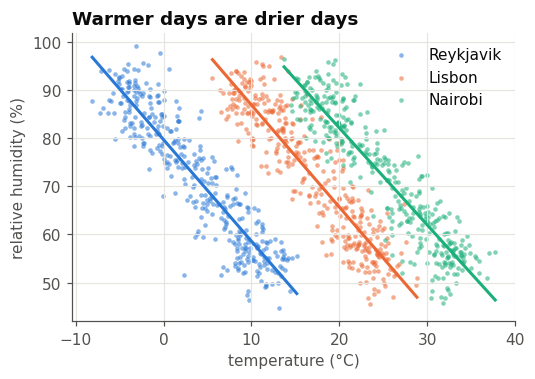

In [7]:
fig, ax = plt.subplots()

for city, color in SERIES.items():
    group = weather[weather.city == city]
    ax.scatter(group.temp_c, group.humidity, s=9, color=color, alpha=0.55,
               linewidths=0, label=city)
    slope, intercept = np.polyfit(group.temp_c, group.humidity, deg=1)
    line = np.array([group.temp_c.min(), group.temp_c.max()])
    ax.plot(line, slope * line + intercept, color=color, lw=2)

ax.set(title="Warmer days are drier days", xlabel="temperature (°C)",
       ylabel="relative humidity (%)")
ax.legend(loc="upper right")
plt.show()

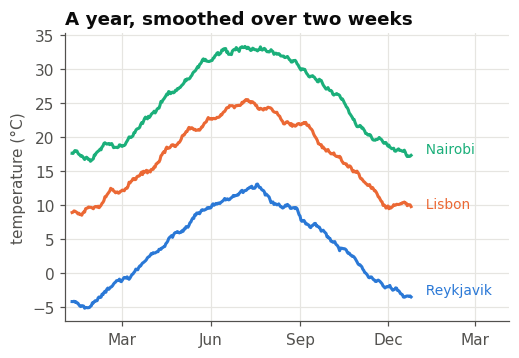

In [8]:
smooth = (weather.pivot_table(index="date", columns="city", values="temp_c")
                 .rolling(14, center=True).mean())

fig, ax = plt.subplots()
for city, color in SERIES.items():
    ax.plot(smooth.index, smooth[city], color=color, lw=2)
    ax.text(smooth.index[-1], smooth[city].iloc[-20], f"  {city}",
            color=color, va="center", fontsize=9)

ax.set(title="A year, smoothed over two weeks", ylabel="temperature (°C)",
       xlim=(smooth.index[0], smooth.index[-1] + pd.Timedelta(days=95)))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
plt.show()

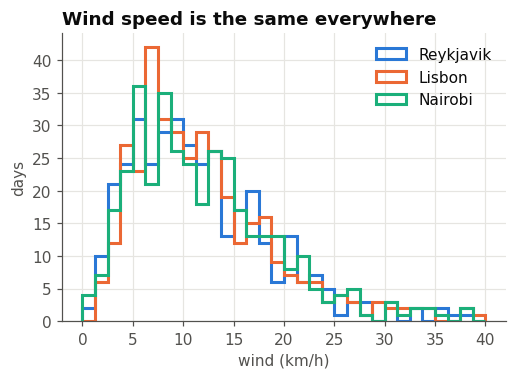

In [9]:
fig, ax = plt.subplots()

edges = np.linspace(0, 40, 33)
for city, color in SERIES.items():
    ax.hist(weather.wind_kph[weather.city == city], bins=edges, histtype="step",
            lw=2, color=color, label=city)

ax.set(title="Wind speed is the same everywhere", xlabel="wind (km/h)",
       ylabel="days")
ax.legend()
plt.show()




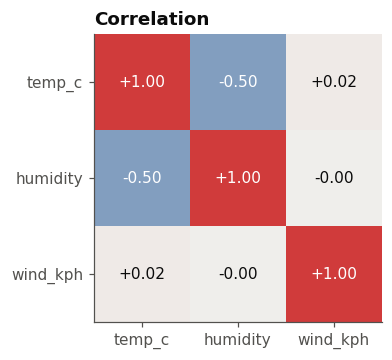

In [10]:
columns = ["temp_c", "humidity", "wind_kph"]
correlation = weather[columns].corr()

fig, ax = plt.subplots()
ax.imshow(correlation, cmap=divergent, vmin=-1, vmax=1)
ax.set(title="Correlation", xticks=range(3), yticks=range(3),
       xticklabels=columns, yticklabels=columns)
ax.grid(False)

for (i, j), value in np.ndenumerate(correlation.to_numpy()):
    ax.text(j, i, f"{value:+.2f}", ha="center", va="center",
            color="white" if abs(value) > 0.5 else INK)

plt.show()

## 4 · A signal, and what it is made of

The same two seconds of sound, read twice: once as it arrives, once as a
spectrum. Nothing but an FFT stands between the two.

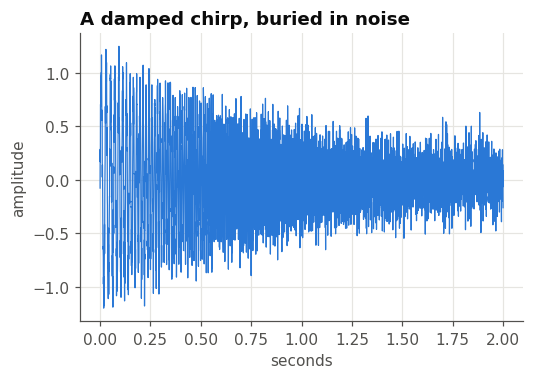

In [11]:
seconds, rate = 2.0, 2000
t = np.linspace(0, seconds, int(seconds * rate), endpoint=False)

chirp = np.sin(2 * np.pi * (40 + 60 * t) * t)
signal = chirp * np.exp(-t) + rng.normal(0, 0.15, t.size)

fig, ax = plt.subplots()
ax.plot(t, signal, color=SERIES["Reykjavik"], lw=0.8)
ax.set(title="A damped chirp, buried in noise", xlabel="seconds",
       ylabel="amplitude")
plt.show()

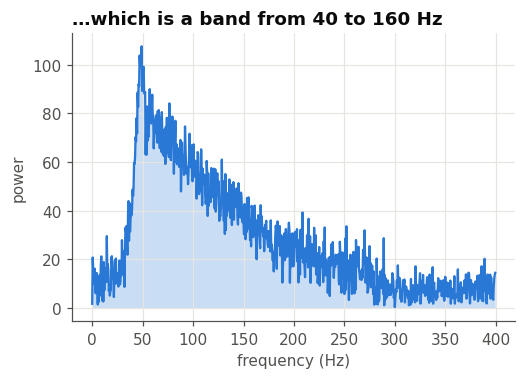

In [12]:
spectrum = np.abs(np.fft.rfft(signal))
frequency = np.fft.rfftfreq(t.size, d=1 / rate)
keep = frequency < 400

fig, ax = plt.subplots()
ax.fill_between(frequency[keep], spectrum[keep], color=SERIES["Reykjavik"],
                alpha=0.25, lw=0)
ax.plot(frequency[keep], spectrum[keep], color=SERIES["Reykjavik"], lw=1.5)
ax.set(title="…which is a band from 40 to 160 Hz", xlabel="frequency (Hz)",
       ylabel="power")
plt.show()

## 5 · Two things you can only do by simulating them

## Monte Carlo Methods

Using random noise for efficient numerical calculations


Monte Carlo integration solves the problem of computing the definite integral I over the area defined by $\Omega$, which in this simple case is just the 1D interval defined by $[a, b]$.
$$
I = \int_\Omega f(x) dx
$$
The idea of Monte Carlo integration is that this definite integral can be approximated by evaluating the function f(x) at N randomly sampled points in this interval: $x_1, .... x_n \in \Omega$, resulting in the approximation below for the original integral:

$$
I \approx Q_N = (b-a) \frac{1}{N} \sum_{i=1}^{N} f(x) = (b-a)\langle f \rangle
$$

Where $\langle f \rangle$ represents the expectation value off over this interval. Given the estimation of I from $Q_N$, the error can be estimated by the sample variance:

$$
Var(f) = \sigma^2_N = \frac{1}{N-1} \sum_{i=1}^N (f(x)-\langle f \rangle)^2
$$

Which then leads to:

$$
Var(Q_N) = \frac{(b-a)^2}{N^2} \sum_{i=1}^{N} Var(f) = \frac{(b-a)^2}{N} \sigma^2_N
$$

The estimation of the error of $Q_N$ is thus given by the expression below, where we see that we obtain the scaling law where the error in our estimate is proportional to $1/\sqrt{N}$, where N is the number of samples

$$
\delta Q_N \approx \sqrt{Var(Q_N)} = \frac{(b-a)\sigma_N}{\sqrt{N}} \propto \frac{1}{\sqrt{N}}
$$


*from https://medium.com/data-science/a-gentle-introduction-to-monte-carlo-methods-98451674018d*

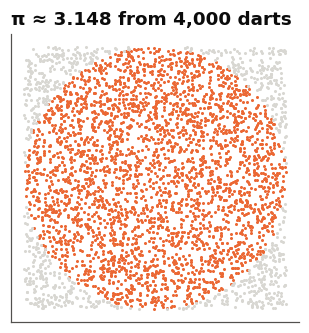

In [13]:
points = rng.uniform(-1, 1, size=(4000, 2))
inside = (points ** 2).sum(axis=1) <= 1

fig, ax = plt.subplots()
ax.scatter(*points[inside].T, s=4, color=SERIES["Lisbon"], linewidths=0)
ax.scatter(*points[~inside].T, s=4, color="#d8d7d2", linewidths=0)
ax.set(title=f"π ≈ {4 * inside.mean():.3f} from {len(points):,} darts",
       aspect="equal", xticks=[], yticks=[])
ax.grid(False)
plt.show()

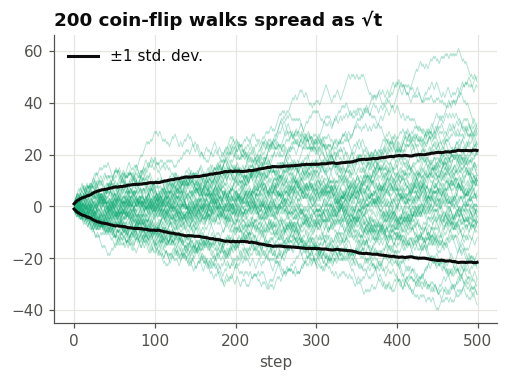

In [14]:
steps = rng.choice([-1.0, 1.0], size=(200, 500))
walks = steps.cumsum(axis=1)

fig, ax = plt.subplots()
ax.plot(walks[:60].T, color=SERIES["Nairobi"], lw=0.6, alpha=0.35)
ax.plot(walks.std(axis=0), color=INK, lw=2, label="±1 std. dev.")
ax.plot(-walks.std(axis=0), color=INK, lw=2)
ax.set(title="200 coin-flip walks spread as √t", xlabel="step")
ax.legend(loc="upper left")
plt.show()

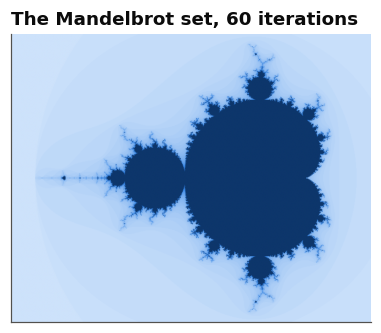

In [15]:
x = np.linspace(-2.2, 0.8, 700)
y = np.linspace(-1.2, 1.2, 560)
c = x + 1j * y[:, None]

z = np.zeros_like(c)
escaped = np.zeros(c.shape, dtype=int)
for i in range(60):
    alive = np.abs(z) < 2
    z[alive] = z[alive] ** 2 + c[alive]
    escaped[alive] = i

fig, ax = plt.subplots()
ax.imshow(escaped, cmap=blue, extent=(-2.2, 0.8, -1.2, 1.2))
ax.set(title="The Mandelbrot set, 60 iterations", xticks=[], yticks=[])
ax.grid(False)
plt.show()

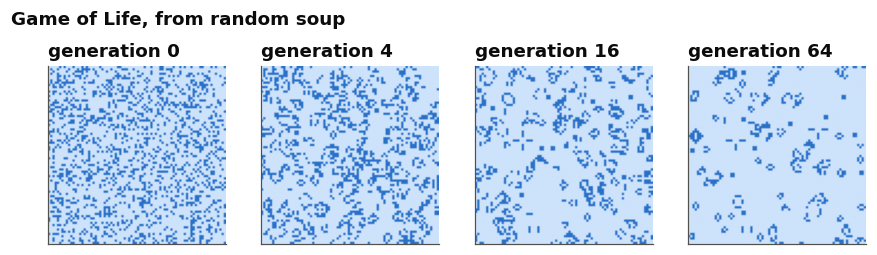

In [16]:
def step(board):
    """One generation of Conway's Game of Life."""
    neighbours = sum(
        np.roll(np.roll(board, dy, axis=0), dx, axis=1)
        for dy in (-1, 0, 1) for dx in (-1, 0, 1)
        if (dy, dx) != (0, 0)
    )
    return (neighbours == 3) | (board & (neighbours == 2))


board = rng.random((80, 80)) < 0.25
snapshots = {}
for generation in range(65):
    if generation in (0, 4, 16, 64):
        snapshots[generation] = board
    board = step(board)

fig, axes = plt.subplots(1, 4, figsize=(9.6, 2.7))
for ax, (generation, frame) in zip(axes, snapshots.items()):
    ax.imshow(frame, cmap=blue, vmin=0, vmax=1.6)
    ax.set(title=f"generation {generation}", xticks=[], yticks=[])
    ax.grid(False)

fig.suptitle("Game of Life, from random soup", x=0.09, ha="left",
             fontweight="semibold")
plt.show()

---

**That is the whole tour.** A table, six charts, two pictures — and the
layout you are reading it in is stored in this notebook's own metadata, so
it travels with the file.

## 7 · Two ways to say what tomorrow will be like

Take the weather table from the top of the notebook and try to forecast each
day's temperature. Both methods below only ever see the past; both are scored
on the same three months they never saw, by the same rule. They are built quite
differently — one fits a formula to a whole season, the other just looks at
last week — and the pictures they produce differ accordingly.

In [17]:
train = weather[weather.date < "2026-10-01"]
test = weather[weather.date >= "2026-10-01"]

scores = {}  # method -> city -> RMSE, filled in by each column


def rmse(errors):
    return float(np.sqrt(np.mean(np.square(errors))))


print(f"train on {train.date.nunique()} days, score on the {test.date.nunique()} after")

train on 273 days, score on the 92 after


# Comparison of method A and B

### A · Ask the calendar

A year of temperature is close to a sine wave. Fit one per city to the training
months by least squares — offset, plus a sine and a cosine, which together give
any phase — and read the forecast straight off the curve.

In [18]:
def seasonal(dates):
    """Design matrix: a constant, and a sine and cosine of the day of year."""
    angle = 2 * np.pi * dates.dt.dayofyear / 365
    return np.c_[np.ones(len(dates)), np.sin(angle), np.cos(angle)]


fits = {}
for city, group in train.groupby("city"):
    fits[city], *_ = np.linalg.lstsq(seasonal(group.date), group.temp_c, rcond=None)

pd.DataFrame(fits, index=["offset", "sin", "cos"]).T.assign(
    amplitude=lambda f: np.hypot(f["sin"], f["cos"])
).round(2)

,offset,sin,cos,amplitude
Lisbon,16.93,-0.96,-7.66,7.72
Nairobi,25.17,-1.49,-8.02,8.16
Reykjavik,3.67,-1.09,-8.04,8.12


In [19]:
calendar = test.assign(
    forecast=lambda t: [seasonal(t.date)[i] @ fits[c] for i, c in enumerate(t.city)]
)
scores["calendar"] = calendar.groupby("city").apply(
    lambda g: rmse(g.temp_c - g.forecast), include_groups=False
)
scores["calendar"].round(2).to_frame("RMSE (°C)")

,RMSE (°C)
city,
Lisbon,1.92
Nairobi,1.74
Reykjavik,1.72


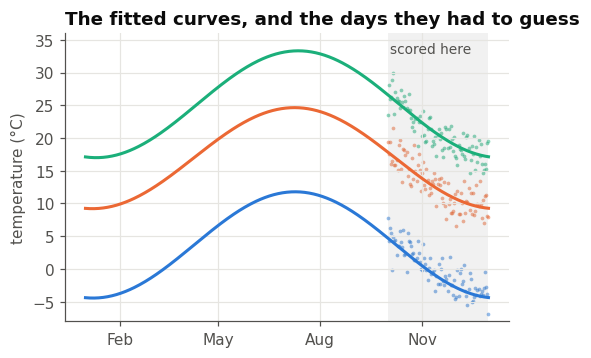

In [20]:
fig, ax = plt.subplots()
year = pd.DataFrame({"date": pd.date_range("2026-01-01", "2026-12-31")})
for city, color in SERIES.items():
    ax.plot(year.date, seasonal(year.date) @ fits[city], color=color, lw=2)
    held = test[test.city == city]
    ax.scatter(held.date, held.temp_c, s=6, color=color, alpha=0.5, linewidths=0)
ax.axvspan(pd.Timestamp("2026-10-01"), pd.Timestamp("2026-12-31"), color=MUTED,
           alpha=0.08, lw=0)
ax.text(pd.Timestamp("2026-10-03"), 33, "scored here", color=MUTED, fontsize=9)
ax.set(title="The fitted curves, and the days they had to guess",
       ylabel="temperature (°C)", ylim=(-8, 36))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
plt.show()

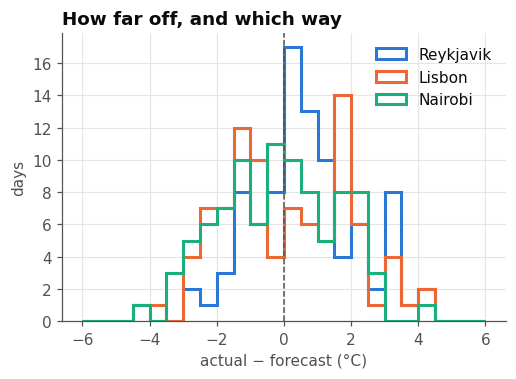

In [21]:
fig, ax = plt.subplots()
edges = np.linspace(-6, 6, 25)
for city, color in SERIES.items():
    miss = calendar[calendar.city == city]
    ax.hist(miss.temp_c - miss.forecast, bins=edges, histtype="step", lw=2,
            color=color, label=city)
ax.axvline(0, color=MUTED, lw=1, ls="--")
ax.set(title="How far off, and which way", xlabel="actual − forecast (°C)",
       ylabel="days")
ax.legend()
plt.show()

### B · Ask yesterday

No formula at all. Tomorrow will be about what the last week was: the mean of
the previous seven days, per city, shifted so no day can see itself. Two lines
of pandas, and a forecast that needs no training at all.

In [22]:
last_week = weather.groupby("city").temp_c.transform(
    lambda s: s.shift(1).rolling(7).mean()
)
misses = test.assign(forecast=last_week[test.index]).assign(
    error=lambda t: t.temp_c - t.forecast
)

scores["yesterday"] = misses.groupby("city").error.apply(rmse)
misses.groupby("city").error.agg(RMSE=rmse, bias="mean").round(2)

,RMSE,bias
city,,
Lisbon,2.05,-0.37
Nairobi,1.90,-0.42
Reykjavik,1.81,-0.41


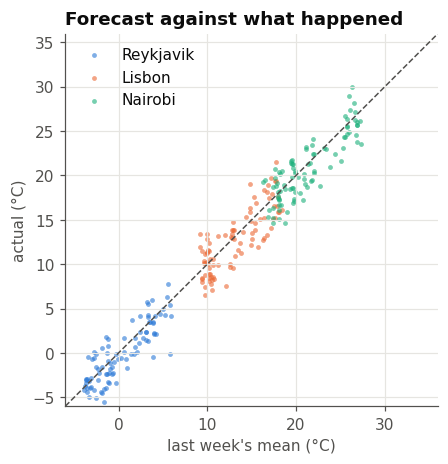

In [23]:
fig, ax = plt.subplots(figsize=(4.4, 4.4))
lo, hi = -6, 36
ax.plot([lo, hi], [lo, hi], color=MUTED, lw=1, ls="--")
for city, color in SERIES.items():
    m = misses[misses.city == city]
    ax.scatter(m.forecast, m.temp_c, s=10, color=color, alpha=0.6, linewidths=0,
               label=city)
ax.set(title="Forecast against what happened", xlabel="last week's mean (°C)",
       ylabel="actual (°C)", xlim=(lo, hi), ylim=(lo, hi), aspect="equal")
ax.legend(loc="upper left")
plt.show()

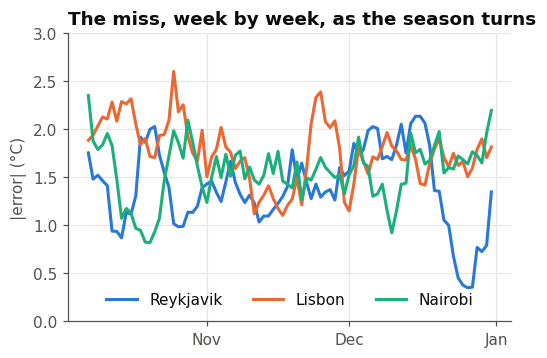

In [24]:
fig, ax = plt.subplots()
for city, color in SERIES.items():
    m = misses[misses.city == city].set_index("date")
    ax.plot(m.error.abs().rolling(7).mean(), color=color, lw=2, label=city)
ax.set(title="The miss, week by week, as the season turns", ylabel="|error| (°C)",
       ylim=(0, 3))
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.legend(loc="lower center", ncol=3)
plt.show()

Same days, same score, both methods. The curve wins — but only just, and a
forecast with no model in it at all is within half a degree of one with.

# Overall Comparison

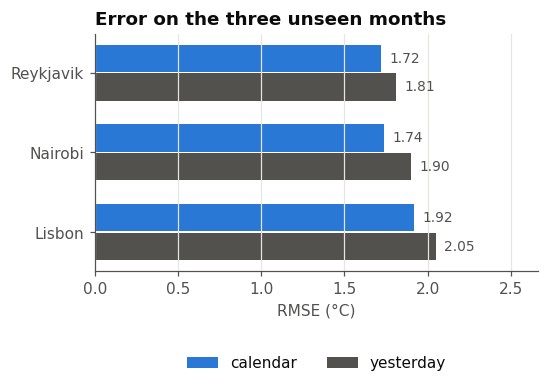

In [25]:
table = pd.DataFrame(scores).round(2)
table["edge"] = (table.yesterday - table.calendar).round(2)

fig, ax = plt.subplots(figsize=(5.2, 2.8))
y = np.arange(len(table))
ax.barh(y + 0.18, table.calendar, height=0.34, color=SERIES["Reykjavik"], label="calendar")
ax.barh(y - 0.18, table.yesterday, height=0.34, color=MUTED, label="yesterday")
for yy, (a, b) in enumerate(zip(table.calendar, table.yesterday)):
    ax.text(a + 0.05, yy + 0.18, f"{a:.2f}", va="center", fontsize=9, color=MUTED)
    ax.text(b + 0.05, yy - 0.18, f"{b:.2f}", va="center", fontsize=9, color=MUTED)
ax.set(title="Error on the three unseen months", xlabel="RMSE (°C)", yticks=y,
       yticklabels=table.index, xlim=(0, table.values[:, :2].max() * 1.3))
ax.grid(axis="y", visible=False)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.3), ncol=2)
plt.show()

In [26]:
table.rename(columns={"edge": "calendar's edge (°C)"})

,calendar,yesterday,calendar's edge (°C)
city,,,
Lisbon,1.92,2.05,0.13
Nairobi,1.74,1.90,0.16
Reykjavik,1.72,1.81,0.09
